#  Uber Data Analysis Project (EDA & Feature Engineering)

###  Project Overview
This project focuses on analyzing real-world Uber trip data to uncover hidden patterns, customer behaviors, and operational insights. As a Data Analyst, the goal is to help Uber optimize its services by solving key business questions through Exploratory Data Analysis (EDA).

---

###  Key Business Objectives
We have performed data manipulation and visualization to answer the following core questions required by the company:
1. **Top Booking Category:** In which category do people book the most Uber rides? (Business vs. Personal)
2. **Primary Purpose:** For which purpose do people book Uber rides the most?
3. **Peak Hours:** At what time do people book cabs the most from Uber?
4. **Low-Demand Months:** In which months do people book Uber rides less frequently?
5. **Peak Days:** On which days of the week do people book Uber rides the most?
6. **Average Trip Distance:** How many miles do people usually book a cab for through Uber?

---

###  Tech Stack & Skills Demonstrated
* **Language:** Python
* **Data Manipulation:** Pandas, NumPy
* **Data Visualization:** Seaborn, Matplotlib
* **Key Concepts:** Feature Engineering (Date-Time extraction), Outlier Handling (Boxplot filtering), Categorical Data Analysis.


# 1. Import Libraries

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
# load dataset

dataset = pd.read_csv('uber.csv')

dataset.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [56]:
dataset.shape

(1156, 7)

In [57]:
dataset.describe(include='all')

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
count,1156,1155,1155,1155,1155,1156.000000,653
unique,1155,1154,2,177,188,NaN,10
top,6/28/2016 23:34,6/28/2016 23:59,Business,Cary,Cary,NaN,Meeting
freq,2,2,1078,201,203,NaN,187
mean,NaN,NaN,NaN,NaN,NaN,21.115398,NaN
std,NaN,NaN,NaN,NaN,NaN,359.299007,NaN
min,NaN,NaN,NaN,NaN,NaN,0.500000,NaN
25%,NaN,NaN,NaN,NaN,NaN,2.900000,NaN
50%,NaN,NaN,NaN,NaN,NaN,6.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,10.400000,NaN


In [58]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   START_DATE*  1156 non-null   object 
 1   END_DATE*    1155 non-null   object 
 2   CATEGORY*    1155 non-null   object 
 3   START*       1155 non-null   object 
 4   STOP*        1155 non-null   object 
 5   MILES*       1156 non-null   float64
 6   PURPOSE*     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


### need some operation
1. change data type object to datatime => Start Data and END_DATE

2. handle null values in => Purpose column

## Data Preprocessing



In [59]:
# fill NaN value
dataset['PURPOSE*'].fillna('NOT',inplace=True)
dataset.head()

/tmp/ipykernel_2049/1686175737.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['PURPOSE*'].fillna('NOT',inplace=True)


,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NOT
2,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [60]:
# change start and end type

dataset['START_DATE*'] = pd.to_datetime(dataset['START_DATE*'],errors='coerce')
dataset['END_DATE*'] = pd.to_datetime(dataset['END_DATE*'],errors='coerce')

In [61]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   START_DATE*  1155 non-null   datetime64[ns]
 1   END_DATE*    1155 non-null   datetime64[ns]
 2   CATEGORY*    1155 non-null   object        
 3   START*       1155 non-null   object        
 4   STOP*        1155 non-null   object        
 5   MILES*       1156 non-null   float64       
 6   PURPOSE*     1156 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(4)
memory usage: 63.3+ KB


## Feature Engineering: Extracting Date and Time,Month and Day from Start Date

In [62]:
from datetime import datetime

dataset['date'] = pd.DatetimeIndex(dataset['START_DATE*']).date
dataset['time'] = pd.DatetimeIndex(dataset['START_DATE*']).hour

dataset.head(2)

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,date,time
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1.0


In [63]:
dataset['day-night'] = pd.cut(x=dataset['time'], bins = [0,10,15,19,24], labels=['Morning','Aafternoon','Evening','Night'])

In [64]:

dataset['MONTH'] = dataset['START_DATE*'].dt.strftime('%b')

mon = dataset['MONTH'].value_counts(sort=True)

print(mon)


MONTH
Dec    146
Aug    133
Nov    122
Feb    115
Mar    113
Jul    112
Jun    108
Oct    106
Jan     61
Apr     54
May     49
Sep     36
Name: count, dtype: int64


In [65]:
dataset.head(2)

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,date,time,day-night,MONTH
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,Night,Jan
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1.0,Morning,Jan


In [66]:
dataset.shape

(1156, 11)

In [67]:
dataset.dropna(inplace=True)

In [68]:
dataset.shape

(1136, 11)

In [69]:
dataset['CATEGORY*'].value_counts()

,count
CATEGORY*,
Business,1061
Personal,75


# 2. Data Visualization

### In which category do people book the most Uber rides?

/tmp/ipykernel_2049/3289570644.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(data=dataset, x='CATEGORY*', palette='viridis', order=dataset['CATEGORY*'].value_counts().index)
/tmp/ipykernel_2049/3289570644.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(data=dataset, y='PURPOSE*', palette='mako', order=dataset['PURPOSE*'].value_counts().index)


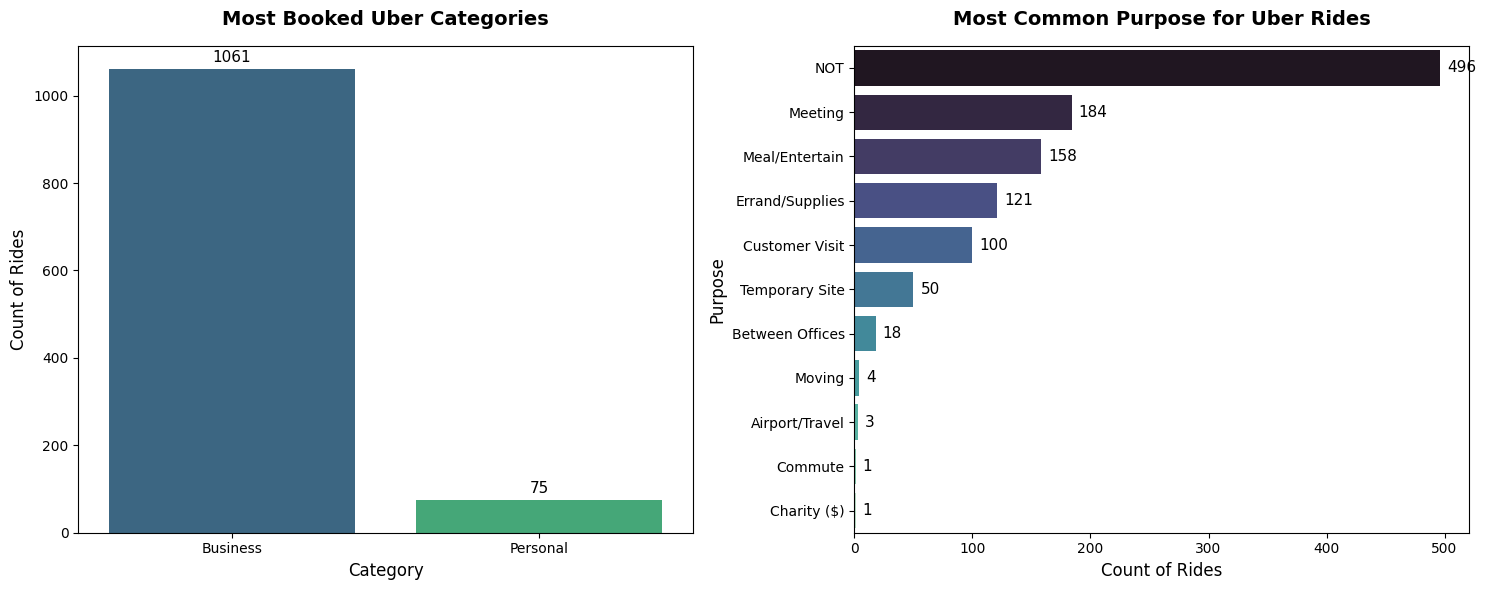

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
ax1 = sns.countplot(data=dataset, x='CATEGORY*', palette='viridis', order=dataset['CATEGORY*'].value_counts().index)
plt.title('Most Booked Uber Categories', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count of Rides', fontsize=12)

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.subplot(1, 2, 2)
ax2 = sns.countplot(data=dataset, y='PURPOSE*', palette='mako', order=dataset['PURPOSE*'].value_counts().index)
plt.title('Most Common Purpose for Uber Rides', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Count of Rides', fontsize=12)
plt.ylabel('Purpose', fontsize=12)

for p in ax2.patches:
    ax2.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=11, color='black', xytext=(5, 0),
                textcoords='offset points')

plt.tight_layout()
plt.show()


People in the business category make the most bookings.

### At what time do people book cabs the most from Uber?:

<Axes: xlabel='count', ylabel='day-night'>

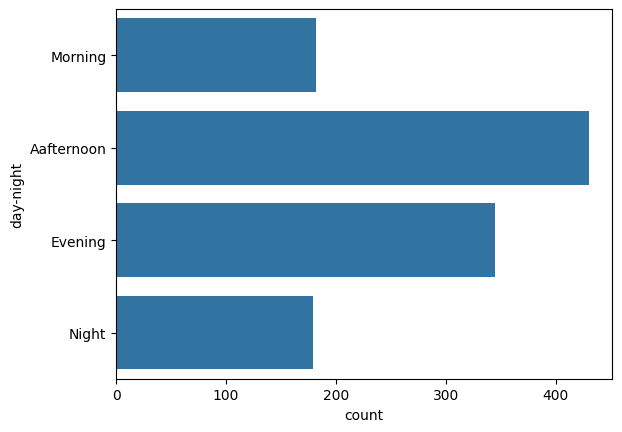

In [71]:
sns.countplot(dataset['day-night'])

### In which months do people book Uber rides less frequently?

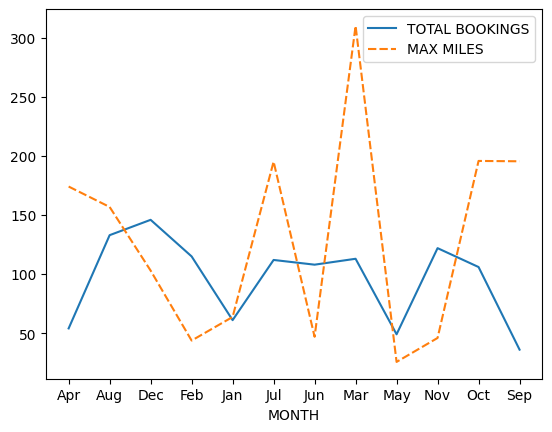

In [72]:
df_plot = pd.DataFrame({'TOTAL BOOKINGS': mon, 'MAX MILES': dataset.groupby('MONTH', sort=False)['MILES*'].max()})

sns.lineplot(data=df_plot)

plt.show()


### On which days of the week do people book Uber rides the most?

In [77]:
dataset['DAY'] = dataset['START_DATE*'].dt.weekday

day_label = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}

dataset['DAY'] = dataset['DAY'].map(day_label)

print(dataset['DAY'].value_counts())


DAY
Friday       204
Tuesday      173
Monday       173
Thursday     151
Saturday     147
Wednesday    145
Sunday       143
Name: count, dtype: int64


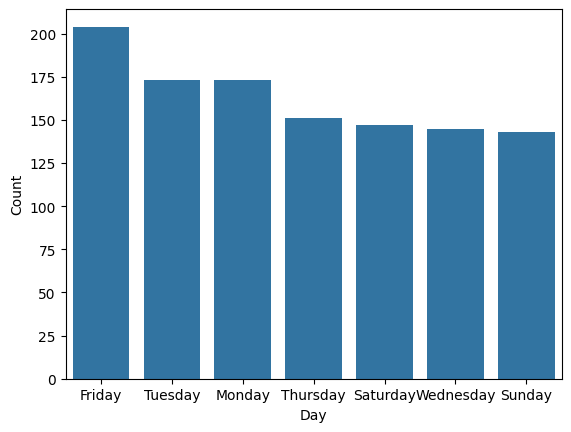

In [79]:
day_label = dataset['DAY'].value_counts()

sns.barplot(x=day_label.index, y=day_label)
plt.xlabel('Day')
plt.ylabel('Count')
plt.show()

### How many miles do people usually book a cab for through Uber?

<Axes: ylabel='MILES*'>

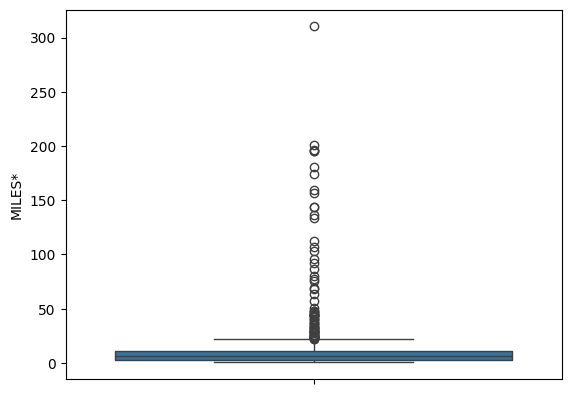

In [80]:
sns.boxplot(dataset['MILES*'])

<Axes: ylabel='MILES*'>

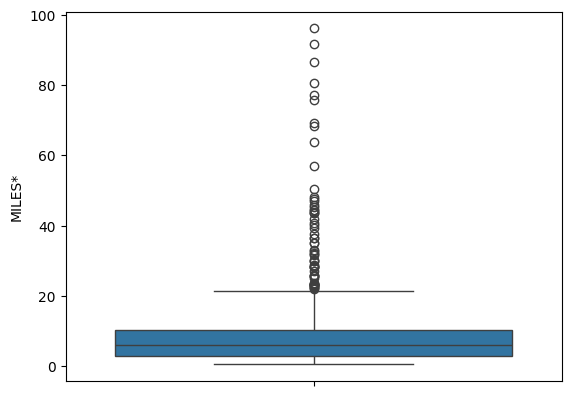

In [86]:
sns.boxplot(dataset[dataset['MILES*']<100]['MILES*'])

<Axes: ylabel='MILES*'>

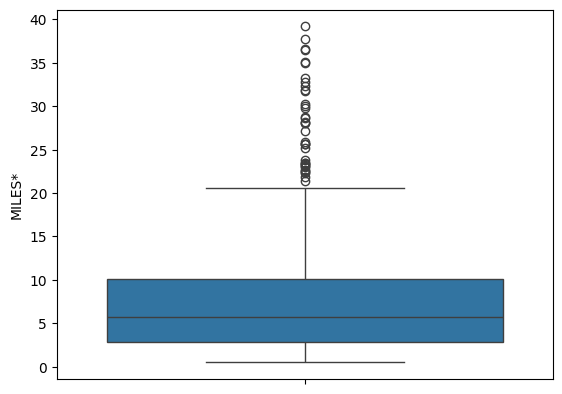

In [87]:
sns.boxplot(dataset[dataset['MILES*']<40]['MILES*'])

/tmp/ipykernel_2049/564126997.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset[dataset['MILES*']<40]['MILES*'])


<Axes: xlabel='MILES*', ylabel='Density'>

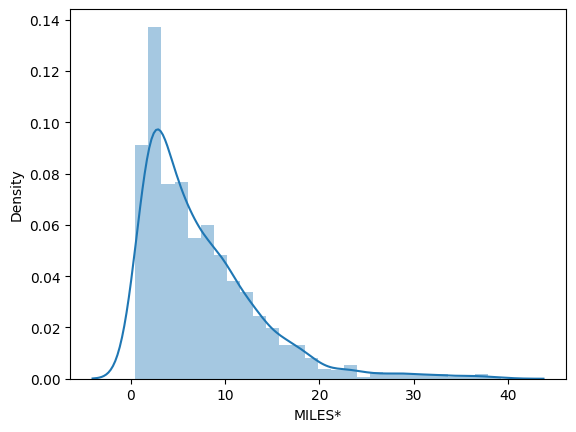

In [88]:
sns.distplot(dataset[dataset['MILES*']<40]['MILES*'])

##  Final Project Conclusion & Insights

Based on the Exploratory Data Analysis (EDA) performed on the Uber dataset, here are the final insights addressing the core business questions:

* **1. Most Booked Category:** **Business rides** dominate the dataset heavily (1,061 bookings) compared to Personal rides (75 bookings). Uber is primarily used for corporate/professional travel in this dataset.
* **2. Primary Purpose:** Excluding missing values, **Meetings** and **Meal/Entertainment** are the top reasons why people book an Uber.
* **3. Peak Time of Day:** Cab bookings are at their highest during the **Afternoon** hours, followed closely by the Evening. Nighttime sees the lowest demand.
* **4. Peak Days of the Week:** **Friday** is the busiest day of the week with the maximum number of rides (204 bookings), while Sunday has the lowest demand (143 bookings).
* **5. Average Trip Distance:** The distribution and boxplots reveal that people usually book Uber for very short distances. Most trips are concentrated between **0 to 10 miles**, with a massive peak around **2 to 5 miles**. Trips longer than 40 miles are extremely rare (treated as Outliers).
